In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import sklearn

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sanderp/badminton-bwf-world-tour/ws.csv
/kaggle/input/datasets/sanderp/badminton-bwf-world-tour/LICENSE
/kaggle/input/datasets/sanderp/badminton-bwf-world-tour/wd.csv
/kaggle/input/datasets/sanderp/badminton-bwf-world-tour/README.md
/kaggle/input/datasets/sanderp/badminton-bwf-world-tour/md.csv
/kaggle/input/datasets/sanderp/badminton-bwf-world-tour/ms.csv
/kaggle/input/datasets/sanderp/badminton-bwf-world-tour/xd.csv


# Introduction
This is a dataset of the Badminton World Tour. In this notebook, we will do some exploration of the dataset, with the main focus being on Men's Singles. There will be a few questions that we will attempt to answer.

For example:

1. *Whether large margin games are more likely to happen in sets that go all the way or sets that are won in as least games as possible*
2. *Are games in the finals less likely to be large margin than overall?*
3. *Does home crowd advantage exist? On average, are players more likely to win in a tournament in their country as opposed to outside?*
4. *Is it true that some regions are stronger than others?*

In [5]:
data = pd.read_csv('/kaggle/input/datasets/sanderp/badminton-bwf-world-tour/ms.csv')
# This is Men's Singles
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3761 entries, 0 to 3760
Data columns (total 38 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   tournament                               3761 non-null   object 
 1   city                                     3761 non-null   object 
 2   country                                  3761 non-null   object 
 3   date                                     3761 non-null   object 
 4   tournament_type                          3761 non-null   object 
 5   discipline                               3761 non-null   object 
 6   round                                    3761 non-null   object 
 7   winner                                   3761 non-null   int64  
 8   nb_sets                                  3761 non-null   int64  
 9   retired                                  3761 non-null   bool   
 10  game_1_score                             3761 no

# Inspection
We first look over and inspect the data. Check for missing values, duplicate rows, etc. 

In [6]:
data.head(10)

,tournament,city,country,date,tournament_type,discipline,round,winner,nb_sets,retired,...,team_one_most_consecutive_points_game_2,team_two_most_consecutive_points_game_2,team_one_game_points_game_2,team_two_game_points_game_2,game_2_scores,team_one_most_consecutive_points_game_3,team_two_most_consecutive_points_game_3,team_one_game_points_game_3,team_two_game_points_game_3,game_3_scores
0,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,False,...,4.0,4.0,2.0,0.0,"['0-0', '0-1', '1-1', '1-2', '2-2', '2-3', '3-...",8.0,2.0,3.0,0.0,"['0-0', '1-0', '1-1', '2-1', '3-1', '4-1', '4-..."
1,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,2,False,...,6.0,5.0,2.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '5-0', '6-...",NaN,NaN,NaN,NaN,[]
2,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,False,...,2.0,6.0,0.0,1.0,"['0-0', '0-1', '0-2', '0-3', '1-3', '2-3', '2-...",4.0,7.0,4.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '4-1', '4-..."
3,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,2,False,...,12.0,3.0,1.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '5-0', '6-...",NaN,NaN,NaN,NaN,[]
4,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,2,2,False,...,3.0,4.0,0.0,2.0,"['0-0', '1-0', '2-0', '3-0', '3-1', '4-1', '4-...",NaN,NaN,NaN,NaN,[]
5,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,2,2,False,...,4.0,5.0,2.0,1.0,"['0-0', '0-1', '1-1', '1-2', '1-3', '1-4', '1-...",NaN,NaN,NaN,NaN,[]
6,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,2,2,False,...,3.0,4.0,0.0,1.0,"['0-0', '0-1', '1-1', '2-1', '2-2', '3-2', '3-...",NaN,NaN,NaN,NaN,[]
7,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,False,...,6.0,3.0,3.0,0.0,"['0-0', '0-1', '1-1', '1-2', '1-3', '1-4', '2-...",3.0,3.0,2.0,0.0,"['0-0', '1-0', '2-0', '2-1', '3-1', '4-1', '5-..."
8,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification quarter final,2,2,False,...,2.0,4.0,0.0,2.0,"['0-0', '0-1', '0-2', '1-2', '1-3', '1-4', '2-...",NaN,NaN,NaN,NaN,[]
9,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,09-01-2018,HSBC BWF World Tour Super 300,MS,Qualification quarter final,2,2,False,...,4.0,4.0,0.0,1.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '4-1', '4-...",NaN,NaN,NaN,NaN,[]


In [7]:
data.describe()

,winner,nb_sets,team_one_total_points,team_two_total_points,team_one_most_consecutive_points,team_two_most_consecutive_points,team_one_game_points,team_two_game_points,team_one_most_consecutive_points_game_1,team_two_most_consecutive_points_game_1,team_one_game_points_game_1,team_two_game_points_game_1,team_one_most_consecutive_points_game_2,team_two_most_consecutive_points_game_2,team_one_game_points_game_2,team_two_game_points_game_2,team_one_most_consecutive_points_game_3,team_two_most_consecutive_points_game_3,team_one_game_points_game_3,team_two_game_points_game_3
count,3761.000000,3761.000000,3761.000000,3761.000000,3761.000000,3761.000000,3761.000000,3761.000000,3761.000000,3761.000000,3761.000000,3761.000000,3723.000000,3723.000000,3723.000000,3723.000000,1302.000000,1302.000000,1302.000000,1302.000000
mean,1.459718,2.339271,41.928476,41.612603,5.665249,5.624568,2.193034,2.086413,4.460516,4.437650,0.962776,0.896570,4.483212,4.405050,0.912168,0.879936,4.570661,4.533794,0.945469,0.920891
std,0.534488,0.493869,12.294976,12.452383,2.155618,2.234039,1.986514,1.946418,1.805016,1.864965,1.205571,1.173144,1.909400,1.931329,1.149291,1.133882,1.880152,1.921602,1.196050,1.206201
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,2.000000,33.000000,32.000000,4.000000,4.000000,0.000000,0.000000,3.000000,3.000000,0.000000,0.000000,3.000000,3.000000,0.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,1.000000,2.000000,42.000000,42.000000,5.000000,5.000000,2.000000,2.000000,4.000000,4.000000,1.000000,1.000000,4.000000,4.000000,1.000000,1.000000,4.000000,4.000000,1.000000,1.000000
75%,2.000000,3.000000,52.000000,52.000000,7.000000,7.000000,3.000000,3.000000,5.000000,5.000000,2.000000,1.000000,5.000000,5.000000,1.000000,1.000000,5.750000,5.000000,1.000000,1.000000
max,2.000000,3.000000,71.000000,69.000000,21.000000,19.000000,11.000000,12.000000,16.000000,15.000000,9.000000,9.000000,18.000000,19.000000,9.000000,9.000000,16.000000,16.000000,8.000000,9.000000


In [8]:
data['round'].value_counts()

round
Round of 32                    1334
Round of 16                     674
Qualification round of 16       436
Round of 64                     345
Quarter final                   338
Qualification round of 32       176
Semi final                      175
Qualification quarter final     159
Final                            88
Round 1                          12
Round 2                          12
Round 3                          12
Name: count, dtype: int64

In [9]:
data.nb_sets.value_counts()

nb_sets
2    2411
3    1313
1      37
Name: count, dtype: int64

This tells us that there are only Bo3 in this dataset

Now we would like to make sure that there is nothign obstensibly wrong with the finals rounds

In [10]:
data[data['round']=='Final'].head(10)

,tournament,city,country,date,tournament_type,discipline,round,winner,nb_sets,retired,...,team_one_most_consecutive_points_game_2,team_two_most_consecutive_points_game_2,team_one_game_points_game_2,team_two_game_points_game_2,game_2_scores,team_one_most_consecutive_points_game_3,team_two_most_consecutive_points_game_3,team_one_game_points_game_3,team_two_game_points_game_3,game_3_scores
42,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,Thailand,14-01-2018,HSBC BWF World Tour Super 300,MS,Final,2,2,False,...,4.0,5.0,0.0,1.0,"['0-0', '0-1', '0-2', '0-3', '0-4', '1-4', '2-...",NaN,NaN,NaN,NaN,[]
84,PERODUA Malaysia Masters 2018,Bukit Jalil,Malaysia,21-01-2018,HSBC BWF World Tour Super 500,MS,Final,1,3,False,...,4.0,4.0,2.0,1.0,"['0-0', '0-1', '1-1', '1-2', '1-3', '1-4', '1-...",4.0,5.0,1.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '4-1', '5-..."
127,DAIHATSU Indonesia Masters 2018,Jakarta,Indonesia,28-01-2018,HSBC BWF World Tour Super 500,MS,Final,2,2,False,...,3.0,5.0,0.0,1.0,"['0-0', '0-1', '0-2', '1-2', '1-3', '1-4', '2-...",NaN,NaN,NaN,NaN,[]
170,YONEX-SUNRISE DR. AKHILESH DAS GUPTA India Ope...,New Delhi,India,04-02-2018,HSBC BWF World Tour Super 500,MS,Final,2,2,False,...,2.0,4.0,0.0,1.0,"['0-0', '0-1', '1-1', '1-2', '2-2', '2-3', '2-...",NaN,NaN,NaN,NaN,[]
213,YONEX Swiss Open 2018,Basel,Switzerland,25-02-2018,HSBC BWF World Tour Super 300,MS,Final,2,2,False,...,3.0,6.0,0.0,1.0,"['0-0', '1-0', '1-1', '1-2', '1-3', '2-3', '3-...",NaN,NaN,NaN,NaN,[]
256,YONEX German Open 2018,Mülheim an der Ruhr,Germany,11-03-2018,HSBC BWF World Tour Super 300,MS,Final,1,3,False,...,3.0,4.0,0.0,1.0,"['0-0', '1-0', '1-1', '2-1', '2-2', '3-2', '3-...",4.0,3.0,4.0,0.0,"['0-0', '1-0', '1-1', '2-1', '3-1', '4-1', '4-..."
287,YONEX All England Open 2018,Birmingham,England,18-03-2018,HSBC BWF World Tour Super 1000,MS,Final,1,3,False,...,3.0,3.0,0.0,1.0,"['0-0', '1-0', '2-0', '2-1', '3-1', '3-2', '4-...",7.0,3.0,1.0,0.0,"['0-0', '1-0', '2-0', '3-0', '3-1', '4-1', '5-..."
356,Orleans Masters 2018,Orleans,France,01-04-2018,BWF Tour Super 100,MS,Final,1,3,False,...,5.0,6.0,1.0,0.0,"['0-0', '0-1', '1-1', '2-1', '3-1', '3-2', '3-...",7.0,2.0,1.0,0.0,"['0-0', '1-0', '2-0', '2-1', '3-1', '4-1', '5-..."
401,Lingshui China Masters 2018,Ling Shui,China,15-04-2018,BWF Tour Super 100,MS,Final,1,3,False,...,8.0,2.0,1.0,0.0,"['0-0', '0-1', '1-1', '2-1', '3-1', '4-1', '5-...",6.0,4.0,1.0,0.0,"['0-0', '1-0', '1-1', '2-1', '3-1', '3-2', '4-..."
444,BARFOOT & THOMPSON New Zealand Open 2018,Auckland,New Zealand,06-05-2018,HSBC BWF World Tour Super 300,MS,Final,1,2,False,...,6.0,5.0,1.0,0.0,"['0-0', '1-0', '1-1', '2-1', '2-2', '2-3', '3-...",NaN,NaN,NaN,NaN,[]


Now we make sure that there is no missing match points data by checking that if there were n games, the nth game score exists. We need only check for n = 2 and n = 3 

In [11]:
# We first check for n = 2 case, if there are 2 sets, there should be a game 2 recorded
data[data.nb_sets == 2]['game_2_scores'].isnull().sum()
# This could have been done in a much simpler way, but checking for n = 3 is easy now


np.int64(0)

In [12]:
data[data.nb_sets == 3]['game_3_scores'].isnull().sum()

np.int64(1)

There seems to be a missing game 3 somewhere

In [13]:
data.loc[(data['nb_sets'] == 3 )& data.game_3_scores.isnull()].iloc[0]

tournament                                                                   Korea Open 2019
city                                                                                 Incheon
country                                                                                Korea
date                                                                              24-09-2019
tournament_type                                                HSBC BWF World Tour Super 500
discipline                                                                                MS
round                                                              Qualification round of 16
winner                                                                                     2
nb_sets                                                                                    3
retired                                                                                False
game_1_score                                                          

It turns out this is just a problem with the dataset, the BWF records have this match recorded, although only the final scores. This shouldn't be a problem since we do not need such specific information as the exact game scores, only the final scores

# Introducing some features
Now we introduce some features. Not all BWF tournaments are equal, some tournaments are more important than others, so we add an additional column dedicated to the tier of the tournament.

For our purposes, we also will need to know the region that each player is from, so we add a player region column.

In [14]:
data.tournament_type.value_counts()

tournament_type
BWF Tour Super 100                1338
HSBC BWF World Tour Super 300     1053
HSBC BWF World Tour Super 500      680
HSBC BWF World Tour Super 750      340
HSBC BWF World Tour Super 1000     305
HSBC BWF World Tour Finals          45
Name: count, dtype: int64

We convert country into country codes.

In [15]:
code_country = {'AFG': 'Afghanistan', 'ALB': 'Albania', 'ALG': 'Algeria', 
                 'AND': 'Andorra', 'ANG': 'Angola', 'ANT': 'Antigua and Barbuda', 
                 'ARG': 'Argentina', 'ARM': 'Armenia', 'ARU': 'Aruba', 'ASA': 'American Samoa',
                 'AUS': 'Australia', 'AUT': 'Austria', 'AZE': 'Azerbaijan', 'BAH': 'Bahamas',
                 'BAN': 'Bangladesh', 'BAR': 'Barbados', 'BDI': 'Burundi', 'BEL': 'Belgium',
                 'BEN': 'Benin', 'BER': 'Bermuda', 'BHU': 'Bhutan', 'BIH': 'Bosnia and Herzegovina',
                 'BIZ': 'Belize', 'BLR': 'Belarus', 'BOL': 'Bolivia', 'BOT': 'Botswana',
                 'BRA': 'Brazil', 'BRN': 'Bahrain', 'BRU': 'Brunei', 'BUL': 'Bulgaria', 
                 'BUR': 'Burkina Faso', 'CAF': 'Central African Republic', 'CAM': 'Cambodia',
                 'CAN': 'Canada', 'CAY': 'Cayman Islands', 'CGO': 'Republic of the Congo', 
                 'CHA': 'Chad', 'CHI': 'Chile', 'CHN': 'China', 'CIV': 'Ivory Coast',
                 'CMR': 'Cameroon', 'COD': 'Democratic Republic of the Congo', 'COK': 'Cook Islands', 
                 'COL': 'Colombia', 'COM': 'Comoros', 'CPV': 'Cape Verde', 'CRC': 'Costa Rica', 'CRO': 
                 'Croatia', 'CUB': 'Cuba', 'CYP': 'Cyprus', 'CZE': 'Czech Republic', 'DEN': 'Denmark', 
                 'DJI': 'Djibouti', 'DMA': 'Dominica', 'DOM': 'Dominican Republic', 'ECU': 'Ecuador',
                 'EGY': 'Egypt', 'ERI': 'Eritrea', 'ESA': 'El Salvador', 'ESP': 'Spain', 
                 'EST': 'Estonia', 'ETH': 'Ethiopia', 'FIJ': 'Fiji', 'FIN': 'Finland', 'FRA': 'France',
                 'FSM': 'Federated States of Micronesia', 'GAB': 'Gabon', 'GAM': 'The Gambia', 
                 'GBR': 'Great Britain', 'GBS': 'Guinea-Bissau', 'GEO': 'Georgia', 'GEQ': 'Equatorial Guinea', 
                 'GER': 'Germany', 'GHA': 'Ghana', 'GRE': 'Greece', 'GRN': 'Grenada', 'GUA': 'Guatemala',
                 'GUI': 'Guinea', 'GUM': 'Guam', 'GUY': 'Guyana', 'HAI': 'Haiti', 'HKG': 'Hong Kong', 
                 'HON': 'Honduras', 'HUN': 'Hungary', 'INA': 'Indonesia', 'IND': 'India', 'IRI': 'Iran', 
                 'IRL': 'Ireland', 'IRQ': 'Iraq', 'ISL': 'Iceland', 'ISR': 'Israel', 'ISV': 'Virgin Islands', 
                 'ITA': 'Italy', 'IVB': 'British Virgin Islands', 'JAM': 'Jamaica', 'JOR': 'Jordan',
                 'JPN': 'Japan', 'KAZ': 'Kazakhstan', 'KEN': 'Kenya', 'KGZ': 'Kyrgyzstan', 
                 'KIR': 'Kiribati', 'KOR': 'South Korea', 'KOS': 'Kosovo', 'KSA': 'Saudi Arabia', 
                 'KUW': 'Kuwait', 'LAO': 'Laos', 'LAT': 'Latvia', 'LBA': 'Libya', 'LBN': 'Lebanon', 
                 'LBR': 'Liberia', 'LCA': 'Saint Lucia', 'LES': 'Lesotho', 'LIE': 'Liechtenstein', 
                 'LTU': 'Lithuania', 'LUX': 'Luxembourg', 'MAD': 'Madagascar', 'MAR': 'Morocco',
                 'MAS': 'Malaysia', 'MAW': 'Malawi', 'MDA': 'Moldova', 'MDV': 'Maldives', 'MEX': 'Mexico', 
                 'MGL': 'Mongolia', 'MHL': 'Marshall Islands', 'MKD': 'North Macedonia', 'MLI': 'Mali',
                 'MLT': 'Malta', 'MNE': 'Montenegro', 'MON': 'Monaco', 'MOZ': 'Mozambique', 'MRI': 'Mauritius',
                 'MTN': 'Mauritania', 'MYA': 'Myanmar', 'NAM': 'Namibia', 'NCA': 'Nicaragua', 
                 'NED': 'Netherlands', 'NEP': 'Nepal', 'NGR': 'Nigeria', 'NIG': 'Niger', 'NOR': 'Norway',
                 'NRU': 'Nauru', 'NZL': 'New Zealand', 'OMA': 'Oman', 'PAK': 'Pakistan', 'PAN': 'Panama',
                 'PAR': 'Paraguay', 'PER': 'Peru', 'PHI': 'Philippines', 'PLE': 'Palestine', 'PLW': 'Palau',
                 'PNG': 'Papua New Guinea', 'POL': 'Poland', 'POR': 'Portugal', 'PRK': 'North Korea', 
                 'PUR': 'Puerto Rico', 'QAT': 'Qatar', 'ROU': 'Romania', 'RSA': 'South Africa', 
                 'RUS': 'Russia', 'RWA': 'Rwanda', 'SAM': 'Samoa', 'SEN': 'Senegal', 'SEY': 'Seychelles',
                 'SGP': 'Singapore', 'SKN': 'Saint Kitts and Nevis', 'SLE': 'Sierra Leone', 'SLO': 'Slovenia', 
                 'SMR': 'San Marino', 'SOL': 'Solomon Islands', 'SOM': 'Somalia', 'SRB': 'Serbia', 
                 'SRI': 'Sri Lanka', 'SSD': 'South Sudan', 'STP': 'São Tomé and Príncipe', 'SUD': 'Sudan',
                 'SUI': 'Switzerland', 'SUR': 'Suriname', 'SVK': 'Slovakia', 'SWE': 'Sweden', 
                 'SWZ': 'Eswatini', 'SYR': 'Syria', 'TAN': 'Tanzania', 'TGA': 'Tonga', 'THA': 'Thailand',
                 'TJK': 'Tajikistan', 'TKM': 'Turkmenistan', 'TLS': 'Timor-Leste', 'TOG': 'Togo', 
                 'TPE': 'Chinese Taipei', 'TTO': 'Trinidad and Tobago', 'TUN': 'Tunisia', 
                 'TUR': 'Turkey', 'TUV': 'Tuvalu', 'UAE': 'United Arab Emirates', 'UGA': 'Uganda',
                 'UKR': 'Ukraine', 'URU': 'Uruguay', 'USA': 'United States', 'UZB': 'Uzbekistan', 
                 'VAN': 'Vanuatu', 'VEN': 'Venezuela', 'VIE': 'Vietnam', 'VIN': 'Saint Vincent and the Grenadines',
                 'YEM': 'Yemen', 'ZAM': 'Zambia', 'ZIM': 'Zimbabwe'}
# These codes are taken from the List of IOC country codes wikipedia page
# Unfortuantely the code doesn't work when run from the kaggle notebook so I ran it locally

country_code = {v: k for k, v in code_country.items()}

data['country'] = data['country'].map(country_code)

data['country']

0       THA
1       THA
2       THA
3       THA
4       THA
       ... 
3756    FRA
3757    FRA
3758    FRA
3759    FRA
3760    FRA
Name: country, Length: 3761, dtype: object

In [16]:
data['team_one_nationalities'].unique()

array(['MAS', 'THA', 'IND', 'VIE', 'INA', 'FRA', 'BRA', 'HKG', 'DEN',
       'JPN', 'ISR', 'CAN', 'TPE', 'KOR', 'CHN', 'ENG', 'RUS', 'USA',
       'ESP', 'GER', 'SUI', 'CZE', 'FIN', 'AUT', 'BEL', 'CRO', 'NED',
       'BEN', 'IRL', 'UKR', 'ALG', 'MAR', 'PYF', 'POR', 'SVK', 'NZL',
       'AUS', 'SRI', 'TTO', 'GUA', 'ITA', 'SGP', 'HUN', 'MGL', 'NEP',
       'PHI', 'MYA', 'SWE', 'BUL', 'TUR', 'MDA', 'LUX', 'MRI', 'SCO',
       'POL', 'AZE', 'VEN', 'LAO', 'EST', 'SRB', 'ROU', 'SLO', 'DOM',
       'UZB', 'MAC', 'MEX'], dtype=object)

In [17]:
np.unique(np.concatenate((data['team_one_nationalities'].unique(),data['team_two_nationalities'].unique())))

array(['ALG', 'AUS', 'AUT', 'AZE', 'BEL', 'BEN', 'BRA', 'BUL', 'CAN',
       'CHI', 'CHN', 'CRO', 'CUB', 'CZE', 'DEN', 'DOM', 'ENG', 'ESP',
       'EST', 'FIN', 'FRA', 'GER', 'GUA', 'HKG', 'HUN', 'INA', 'IND',
       'IRL', 'ISL', 'ISR', 'ITA', 'JPN', 'KOR', 'LAO', 'LUX', 'MAC',
       'MAR', 'MAS', 'MDA', 'MEX', 'MGL', 'MRI', 'MYA', 'NED', 'NEP',
       'NZL', 'PHI', 'POL', 'POR', 'PYF', 'ROU', 'RUS', 'SCO', 'SGP',
       'SLO', 'SRB', 'SRI', 'SUI', 'SUR', 'SVK', 'SWE', 'THA', 'TPE',
       'TTO', 'TUR', 'UKR', 'USA', 'UZB', 'VEN', 'VIE'], dtype=object)

In [18]:
data['date'] = pd.to_datetime(data["date"],format = '%d-%m-%Y')
# turn into datetime

data['tournament_tier'] = data['tournament_type'].replace({'BWF Tour Super 100':'Low Tier', 'HSBC BWF World Tour Super 300': 'Low Tier', 'HSBC BWF World Tour Super 500': 'Mid Tier', 'HSBC BWF World Tour Super 750': 'Mid Tier', 'HSBC BWF World Tour Super 1000': 'Top Tier', 'HSBC BWF World Tour Finals': 'Top Tier'})

data["city"] = data["city"].str.strip().str.title()

def into_region(country):
    country = str(country)
    if country in ['ALG', 'BEN', 'MAR', 'MRI']:
        return 'africa'
    elif country in ['CHN', 'HKG', 'INA', 'IND', 'ISR', 'JPN', 'KOR', 'LAO'
                     , 'MAC', 'MAS', 'MGL', 'MYA', 'NEP', 'PHI', 'SGP', 'SRI', 'THA', 'TPE', 'VIE']:
        return 'asia'
    elif country in ['AUT', 'AZE', 'BEL', 'BUL', 'CRO', 'CZE', 'DEN', 'ENG', 'ESP'
                     , 'EST', 'FIN', 'FRA', 'GER', 'HUN', 'IRL', 'ISL', 'ITA', 'LUX','UZB'
                     , 'MDA', 'NED', 'POL', 'POR', 'ROU', 'RUS', 'SCO', 'SLO', 'SRB', 'SUI', 'SVK', 'SWE', 'TUR', 'UKR']:
        return 'europe'
    elif country in ['BRA', 'CAN', 'CHI', 'CUB', 'DOM','GUA', 'MEX', 'SUR', 'TTO', 'USA', 'VEN']:
        return 'americas'
    elif country in ['AUS', 'NZL', 'PYF']:
        return 'oceania'
    else:
        return 'unknown'

data['team_one_region'] = data['team_one_nationalities'].apply(into_region)
data['team_two_region'] = data['team_two_nationalities'].apply(into_region)

data



,tournament,city,country,date,tournament_type,discipline,round,winner,nb_sets,retired,...,team_two_game_points_game_2,game_2_scores,team_one_most_consecutive_points_game_3,team_two_most_consecutive_points_game_3,team_one_game_points_game_3,team_two_game_points_game_3,game_3_scores,tournament_tier,team_one_region,team_two_region
0,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,THA,2018-01-09,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,False,...,0.0,"['0-0', '0-1', '1-1', '1-2', '2-2', '2-3', '3-...",8.0,2.0,3.0,0.0,"['0-0', '1-0', '1-1', '2-1', '3-1', '4-1', '4-...",Low Tier,asia,asia
1,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,THA,2018-01-09,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,2,False,...,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '5-0', '6-...",NaN,NaN,NaN,NaN,[],Low Tier,asia,asia
2,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,THA,2018-01-09,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,False,...,1.0,"['0-0', '0-1', '0-2', '0-3', '1-3', '2-3', '2-...",4.0,7.0,4.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '4-1', '4-...",Low Tier,asia,asia
3,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,THA,2018-01-09,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,2,False,...,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '5-0', '6-...",NaN,NaN,NaN,NaN,[],Low Tier,asia,asia
4,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,THA,2018-01-09,HSBC BWF World Tour Super 300,MS,Qualification round of 16,2,2,False,...,2.0,"['0-0', '1-0', '2-0', '3-0', '3-1', '4-1', '4-...",NaN,NaN,NaN,NaN,[],Low Tier,asia,asia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3756,Orleans Masters 2021 (New Dates),Orleans,FRA,2021-03-26,BWF Tour Super 100,MS,Quarter final,2,2,False,...,5.0,"['0-0', '1-0', '2-0', '2-1', '3-1', '3-2', '3-...",NaN,NaN,NaN,NaN,[],Low Tier,europe,europe
3757,Orleans Masters 2021 (New Dates),Orleans,FRA,2021-03-26,BWF Tour Super 100,MS,Quarter final,1,2,False,...,0.0,"['0-0', '1-0', '2-0', '3-0', '3-1', '4-1', '5-...",NaN,NaN,NaN,NaN,[],Low Tier,europe,europe
3758,Orleans Masters 2021 (New Dates),Orleans,FRA,2021-03-27,BWF Tour Super 100,MS,Semi final,1,3,False,...,1.0,"['0-0', '1-0', '1-1', '1-2', '2-2', '2-3', '2-...",6.0,2.0,1.0,0.0,"['0-0', '1-0', '1-1', '2-1', '3-1', '4-1', '4-...",Low Tier,europe,asia
3759,Orleans Masters 2021 (New Dates),Orleans,FRA,2021-03-27,BWF Tour Super 100,MS,Semi final,2,3,False,...,1.0,"['0-0', '1-0', '2-0', '3-0', '3-1', '3-2', '3-...",4.0,6.0,0.0,2.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '4-1', '4-...",Low Tier,europe,europe


Now, we just check that there are no regions that have been missed

In [19]:
data.loc[(data['team_one_region']=='unknown')|(data['team_two_region']=='unknown')]

,tournament,city,country,date,tournament_type,discipline,round,winner,nb_sets,retired,...,team_two_game_points_game_2,game_2_scores,team_one_most_consecutive_points_game_3,team_two_most_consecutive_points_game_3,team_one_game_points_game_3,team_two_game_points_game_3,game_3_scores,tournament_tier,team_one_region,team_two_region


We also will add in an average margin feature to each matchup.

In [20]:
def evaluation(score):
    score_list = score.split('-')
    score_list = [int(i) for i in score_list]
    return score_list[0]-score_list[1]

def margin_collector(score):
    return abs(evaluation(score))
# score is recorded in the form 21-17 so the margin is just the absolute value of the evaluation

def avg_margin(row):
    if row.nb_sets == 2:
        return (margin_collector(row.game_1_score)+margin_collector(row.game_2_score))/2
    elif row.nb_sets == 3:
        return (margin_collector(row.game_1_score)+margin_collector(row.game_2_score)+margin_collector(row.game_3_score))/3
    else:
        return 0
data['avg_margin'] = data.apply(avg_margin, axis = 'columns')

data.head()

,tournament,city,country,date,tournament_type,discipline,round,winner,nb_sets,retired,...,game_2_scores,team_one_most_consecutive_points_game_3,team_two_most_consecutive_points_game_3,team_one_game_points_game_3,team_two_game_points_game_3,game_3_scores,tournament_tier,team_one_region,team_two_region,avg_margin
0,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,THA,2018-01-09,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,False,...,"['0-0', '0-1', '1-1', '1-2', '2-2', '2-3', '3-...",8.0,2.0,3.0,0.0,"['0-0', '1-0', '1-1', '2-1', '3-1', '4-1', '4-...",Low Tier,asia,asia,8.333333
1,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,THA,2018-01-09,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,2,False,...,"['0-0', '1-0', '2-0', '3-0', '4-0', '5-0', '6-...",NaN,NaN,NaN,NaN,[],Low Tier,asia,asia,8.500000
2,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,THA,2018-01-09,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,False,...,"['0-0', '0-1', '0-2', '0-3', '1-3', '2-3', '2-...",4.0,7.0,4.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '4-1', '4-...",Low Tier,asia,asia,6.666667
3,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,THA,2018-01-09,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,2,False,...,"['0-0', '1-0', '2-0', '3-0', '4-0', '5-0', '6-...",NaN,NaN,NaN,NaN,[],Low Tier,asia,asia,9.000000
4,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,THA,2018-01-09,HSBC BWF World Tour Super 300,MS,Qualification round of 16,2,2,False,...,"['0-0', '1-0', '2-0', '3-0', '3-1', '4-1', '4-...",NaN,NaN,NaN,NaN,[],Low Tier,asia,asia,8.000000


# Cleaning and Preprocessing
Now that we have made sure there are no major issues, we clean. Turn the date into datetime, and get rid of columns that will not be used. Since none of our analysis requries incredibly fine details of every game but rather the match as a whole, we will get rid of the per-game details.

This has the advantage of also getting rid of the many NaNs present. 

In [21]:
data

,tournament,city,country,date,tournament_type,discipline,round,winner,nb_sets,retired,...,game_2_scores,team_one_most_consecutive_points_game_3,team_two_most_consecutive_points_game_3,team_one_game_points_game_3,team_two_game_points_game_3,game_3_scores,tournament_tier,team_one_region,team_two_region,avg_margin
0,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,THA,2018-01-09,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,False,...,"['0-0', '0-1', '1-1', '1-2', '2-2', '2-3', '3-...",8.0,2.0,3.0,0.0,"['0-0', '1-0', '1-1', '2-1', '3-1', '4-1', '4-...",Low Tier,asia,asia,8.333333
1,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,THA,2018-01-09,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,2,False,...,"['0-0', '1-0', '2-0', '3-0', '4-0', '5-0', '6-...",NaN,NaN,NaN,NaN,[],Low Tier,asia,asia,8.500000
2,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,THA,2018-01-09,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,3,False,...,"['0-0', '0-1', '0-2', '0-3', '1-3', '2-3', '2-...",4.0,7.0,4.0,0.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '4-1', '4-...",Low Tier,asia,asia,6.666667
3,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,THA,2018-01-09,HSBC BWF World Tour Super 300,MS,Qualification round of 16,1,2,False,...,"['0-0', '1-0', '2-0', '3-0', '4-0', '5-0', '6-...",NaN,NaN,NaN,NaN,[],Low Tier,asia,asia,9.000000
4,PRINCESS SIRIVANNAVARI Thailand Masters 2018,Bangkok,THA,2018-01-09,HSBC BWF World Tour Super 300,MS,Qualification round of 16,2,2,False,...,"['0-0', '1-0', '2-0', '3-0', '3-1', '4-1', '4-...",NaN,NaN,NaN,NaN,[],Low Tier,asia,asia,8.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3756,Orleans Masters 2021 (New Dates),Orleans,FRA,2021-03-26,BWF Tour Super 100,MS,Quarter final,2,2,False,...,"['0-0', '1-0', '2-0', '2-1', '3-1', '3-2', '3-...",NaN,NaN,NaN,NaN,[],Low Tier,europe,europe,8.000000
3757,Orleans Masters 2021 (New Dates),Orleans,FRA,2021-03-26,BWF Tour Super 100,MS,Quarter final,1,2,False,...,"['0-0', '1-0', '2-0', '3-0', '3-1', '4-1', '5-...",NaN,NaN,NaN,NaN,[],Low Tier,europe,europe,9.000000
3758,Orleans Masters 2021 (New Dates),Orleans,FRA,2021-03-27,BWF Tour Super 100,MS,Semi final,1,3,False,...,"['0-0', '1-0', '1-1', '1-2', '2-2', '2-3', '2-...",6.0,2.0,1.0,0.0,"['0-0', '1-0', '1-1', '2-1', '3-1', '4-1', '4-...",Low Tier,europe,asia,8.666667
3759,Orleans Masters 2021 (New Dates),Orleans,FRA,2021-03-27,BWF Tour Super 100,MS,Semi final,2,3,False,...,"['0-0', '1-0', '2-0', '3-0', '3-1', '3-2', '3-...",4.0,6.0,0.0,2.0,"['0-0', '1-0', '2-0', '3-0', '4-0', '4-1', '4-...",Low Tier,europe,europe,6.333333


Here we do some basic cleaning

In [22]:
features = ['tournament_type', 'round', 'nb_sets', 'retired', 
       'team_one_nationalities', 'team_two_nationalities', 'tournament_tier',
       'team_one_region', 'team_two_region', 'avg_margin',
            'team_one_most_consecutive_points', 'team_two_most_consecutive_points']

df = data[features+['winner']].dropna().drop_duplicates()
df = df[df['retired']==False]

In [23]:
df.head()

,tournament_type,round,nb_sets,retired,team_one_nationalities,team_two_nationalities,tournament_tier,team_one_region,team_two_region,avg_margin,team_one_most_consecutive_points,team_two_most_consecutive_points,winner
0,HSBC BWF World Tour Super 300,Qualification round of 16,3,False,MAS,THA,Low Tier,asia,asia,8.333333,8,9,1
1,HSBC BWF World Tour Super 300,Qualification round of 16,2,False,MAS,INA,Low Tier,asia,asia,8.500000,9,5,1
2,HSBC BWF World Tour Super 300,Qualification round of 16,3,False,THA,MAS,Low Tier,asia,asia,6.666667,4,7,1
3,HSBC BWF World Tour Super 300,Qualification round of 16,2,False,IND,INA,Low Tier,asia,asia,9.000000,14,4,1
4,HSBC BWF World Tour Super 300,Qualification round of 16,2,False,IND,JPN,Low Tier,asia,asia,8.000000,4,5,2


In [24]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_features = [ 'nb_sets', 'avg_margin',
            'team_one_most_consecutive_points', 'team_two_most_consecutive_points' ]
cat_features = ['round','tournament_type','team_one_nationalities', 'team_two_nationalities', 'tournament_tier',
       'team_one_region', 'team_two_region', 'retired']

num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown = 'ignore')

preprocessor = ColumnTransformer([('num',num_transformer,num_features),
                                ('cat',cat_transformer,cat_features)])

# Questions
Recall our 4 questions from the introduction, which we are now ready to start answering.

1. Whether large margin games are more likely to happen in sets that go all the way or sets that are won in as least games as possible
2. Are games in the finals less likely to be large margin then overall?
3. Does home crowd advantage exist? On average, are players more likely to win in a tournament in their country as opposed to outside?
4. Is it true that some regions are stronger than others?

## Are Longer Sets More Likely To Have Closer Games?
*Are large margin sets more likely to happen in sets that go all the way or sets that are won in as least games as possible?*

To answer this question, we must first make the question well-posed. A large margin set should be a margin that is quite a bit larger than the average margin of a set, which we will have to compute. After we have determined what a large margin should be, we will check the percentage of sets in games of 2 that have large margins and compare this to the percentage of sets in games of 3 that have large margins

The percentage in question is calculated in the following way

$$\frac{\text{\# of large margin sets(game of n)}}{\text{\# of sets in games of n}}$$

### Analyzing Margins of Sets


In [25]:


margin2 = (data.loc[data['nb_sets']==2][['game_1_score','game_2_score']]
           .apply(lambda row: row.map(margin_collector).sum()).sum())
# We first find all rows that have 2 sets, then take the score columns, apply margin_collector and sum up all games
margin3 = (data.loc[data['nb_sets']==3][['game_1_score','game_2_score','game_3_score']]
           .apply(lambda row: row.map(margin_collector).sum()).sum())

set2 = 2*data.loc[data['nb_sets']==2].shape[0]
# This gives how many games have 2 sets, so the number of sets is this multiplied by 2
set3 = 3*data.loc[data['nb_sets']==3].shape[0]

avg_margin = (margin2 + margin3)/(set2 + set3)

avg_margin



np.float64(6.462390138112088)

The average margin is approximately 6.5, which is quite suprising since a given set is out of 21. The average margin is quite high. There are a few possible explanations, it is possible that there is more potential for a mismatch in the lower tier tournaments, which we can check. 

In [26]:
#This is to calculate low tier tournaments

lt_margin2 = (data.loc[(data['nb_sets']==2)&(data['tournament_tier'] == 'Low Tier')][['game_1_score','game_2_score']]
           .apply(lambda row: row.map(margin_collector).sum()).sum())
lt_margin3 = (data.loc[(data['nb_sets']==3)&(data['tournament_tier'] == 'Low Tier')][['game_1_score','game_2_score','game_3_score']]
           .apply(lambda row: row.map(margin_collector).sum()).sum())

lt_set2 = 2*data.loc[(data['nb_sets']==2)&(data['tournament_tier'] == 'Low Tier')].shape[0]
lt_set3 = 3*data.loc[(data['nb_sets']==3)&(data['tournament_tier'] == 'Low Tier')].shape[0]

lt_avg_margin = (lt_margin2 + lt_margin3)/(lt_set2 + lt_set3)

lt_avg_margin


np.float64(6.513342949873783)

In [27]:
# This is to calculate mid tier tournaments

mt_margin2 = (data.loc[(data['nb_sets']==2)&(data['tournament_tier'] == 'Mid Tier')][['game_1_score','game_2_score']]
           .apply(lambda row: row.map(margin_collector).sum()).sum())
# We first find all rows that have 2 sets, then take the score columns, apply margin_collector and sum up all games
mt_margin3 = (data.loc[(data['nb_sets']==3)&(data['tournament_tier'] == 'Mid Tier')][['game_1_score','game_2_score','game_3_score']]
           .apply(lambda row: row.map(margin_collector).sum()).sum())

mt_set2 = 2*data.loc[(data['nb_sets']==2)&(data['tournament_tier'] == 'Mid Tier')].shape[0]
# This gives how many games have 2 sets, so the number of sets is this multiplied by 2
mt_set3 = 3*data.loc[(data['nb_sets']==3)&(data['tournament_tier'] == 'Mid Tier')].shape[0]

mt_avg_margin = (mt_margin2 + mt_margin3)/(mt_set2 + mt_set3)

mt_avg_margin

np.float64(6.347771761765931)

Suprisingly, it seems that this is not the case. The average margin is approximately the same throughout all tiers of the tournament.

### Distribution of Margin
In order to properly determine what a "large margin game" should be, it would be useful to be able to see the distribution of the margins. 

In [28]:
s21 = data.loc[data['nb_sets']==2]['game_1_score'].apply(margin_collector)
s22 = data.loc[data['nb_sets']==2]['game_2_score'].apply(margin_collector)
s31 = data.loc[data['nb_sets']==3]['game_1_score'].apply(margin_collector)
s32 = data.loc[data['nb_sets']==3]['game_2_score'].apply(margin_collector)
s33 = data.loc[data['nb_sets']==3]['game_3_score'].apply(margin_collector)
# for each combination of set and game, we take the margins

s21 = pd.Series.to_numpy(s21)
s22 = pd.Series.to_numpy(s22)
s31 = pd.Series.to_numpy(s31)
s32 = pd.Series.to_numpy(s32)
s33 = pd.Series.to_numpy(s33)

margin_array = np.concatenate((s21,s22,s31,s32,s33))
# now we concatenate them all together to get a series that contains all the margins

margin2+margin3 - margin_array.sum() 
# this is a quick check to make sure we didn't seriously mess something up


np.int64(0)

In [29]:
print(margin_array.mean())
print(margin_array.std())
print(np.quantile(margin_array,[0.25,0.5,0.75]))
print(np.median(margin_array))

6.462390138112088
3.679765677642951
[3. 6. 9.]
6.0


### Definition of Large Margin

We will define large margin to be above the 75th percentile. In other words, a large margin game is one that ends with a margin of 9 points or higher. 

Now, we plot the distribution. 

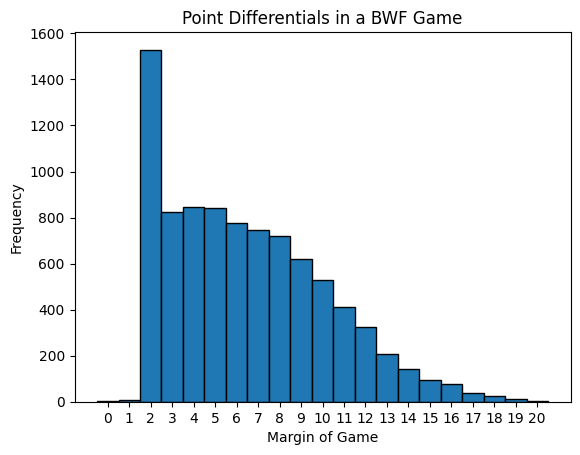

In [30]:
bins = np.arange(margin_array.min(), margin_array.max() + 2) - 0.5
# So the bars are on integer values

plt.hist(margin_array, bins, edgecolor='black')

#x label, y label, title, x tick(give an np.arange)

plt.xlabel('Margin of Game')
plt.ylabel('Frequency')
plt.title('Point Differentials in a BWF Game')

plt.xticks(np.arange(margin_array.min(),margin_array.max()+1))
plt.show()


#### Observations of Margin Distribution

We can make some observations here. The first is that there is a very large number of 2-point differential sets. This is most likely due to games going into overtime which becomes win by 2. However, there is one exception, games in OT must end at 30, which is most likely what caused the 1 point differential games. 



## Answering Question 1
We are now ready to answer question 1. 

*Are large margin sets more likely to happen in sets that go all the way or sets that are won in as least games as possible?*

In [31]:
def is_large_margin(score):
    diff = int(margin_collector(score))
    return diff >= 9

large_margin_2 = (data.loc[data['nb_sets']==2][['game_1_score','game_2_score']]
           .apply(lambda row: row.map(is_large_margin).sum()).sum())
# Large margins games in a sets of 2

large_margin_3 = (data.loc[data['nb_sets']==3][['game_1_score','game_2_score','game_3_score']]
           .apply(lambda row: row.map(is_large_margin).sum()).sum())

large_margin_2/set2 - large_margin_3/set3

np.float64(0.09625206211397389)

In [32]:
(large_margin_2+large_margin_3)/(set2+set3)
# percentage of large margin games overall

np.float64(0.2827302819312864)

We can now see that large margin games are more likely to happen in shorter sets by around 9.6%, which is still quite small but fits with our original intuitition that mismatches are more likely to contain shorter sets and larger game margins. 

## Finals Margin Analysis

*Are games in the finals less likely to be large margin than overall?*

In [33]:
flarge_margin_2 = (data.loc[(data['nb_sets']==2)&(data['round']=='Final')][['game_1_score','game_2_score']]
           .apply(lambda row: row.map(is_large_margin).sum()).sum())
# finals large margin set of 2

flarge_margin_3 = (data.loc[(data['nb_sets']==3)&(data['round']=='Final')][['game_1_score','game_2_score','game_3_score']]
           .apply(lambda row: row.map(is_large_margin).sum()).sum())
# finals large margin set of 3

f_set2 = 2*data.loc[(data['nb_sets']==2)&(data['round'] == 'Final')].shape[0]
f_set3 = 3*data.loc[(data['nb_sets']==3)&(data['round'] == 'Final')].shape[0]
# finals games of sets of 2 and 3
flarge_margin_ratio = (flarge_margin_2 + flarge_margin_3)/(f_set2+f_set3)

flarge_margin_ratio

np.float64(0.24651162790697675)

Interestingly, finals games do not seem to have a very significantly lower chance of having a large margin game
than overall. By definition, there is around a 28.3% chance of having a large margin game, and in the finals there is a 24.6% chance which is not a very sizeable decrease.

## How Does Playing a Game in Home Country Affect Odds of Winning?

*Does home crowd advantage exist? On average, are players more likely to win in a tournament in their country as opposed to outside?*


In [34]:
# the idea here is that we look at whether player 1 or 2 won, 
# then check whether their nationality is the same as the country
# this is easier to do since the country is represented by country codes
# We ignore the cases where both are from the country hosting the tournament

def whome_fn(row):
    if row.team_one_nationalities != row.country and row.team_two_nationalities != row.country:
        return 0
    elif row.team_one_nationalities == row.team_two_nationalities:
        return 0
    elif row['winner'] == 1:
        return row.team_one_nationalities == row.country
    elif row['winner'] == 2:
        return row.team_two_nationalities == row.country
    else:
        return 0
# We ignore the case where both are from the same country
# check if winner 

won_home_count = data.apply(whome_fn, axis= 'columns').sum()

# Now we compare this to the cases where a player loses on home court

def lhome_fn(row):
    if row.team_one_nationalities != row.country and row.team_two_nationalities != row.country:
        return 0
    elif row.team_one_nationalities == row.team_two_nationalities:
        return 0
    elif row['winner'] == 1:
        return row.team_one_nationalities != row.country
    elif row['winner'] == 2:
        return row.team_two_nationalities != row.country
    else:
        return 0
lost_home_count = data.apply(lhome_fn, axis = 'columns').sum()

print(won_home_count)
print(lost_home_count)



395
428


Surprisingly, it seems that players are actually marginally more likely to lose when on home soil. Although, this does only represent around a 7% chance. It also remains to be seen whether this effect still exists in the finals.

In [35]:
# the idea here is that we look at whether player 1 or 2 won, 
# then check whether their nationality is the same as the country
# this is easier to do since the country is represented by country codes
# We ignore the cases where both are from the country hosting the tournament

def whome_fn(row):
    if row.team_one_nationalities != row.country and row.team_two_nationalities != row.country:
        return 0
    elif row.team_one_nationalities == row.team_two_nationalities:
        return 0
    elif row['winner'] == 1:
        return row.team_one_nationalities == row.country
    elif row['winner'] == 2:
        return row.team_two_nationalities == row.country
    else:
        return 0
# We ignore the case where both are from the same country
# check if winner 

fwon_home_count = data.loc[data['round'] == 'Final'].apply(whome_fn, axis= 'columns').sum()

# Now we compare this to the cases where a player loses on home court

def lhome_fn(row):
    if row.team_one_nationalities != row.country and row.team_two_nationalities != row.country:
        return 0
    elif row.team_one_nationalities == row.team_two_nationalities:
        return 0
    elif row['winner'] == 1:
        return row.team_one_nationalities != row.country
    elif row['winner'] == 2:
        return row.team_two_nationalities != row.country
    else:
        return 0
flost_home_count = data.loc[data['round'] == 'Final'].apply(lhome_fn, axis = 'columns').sum()

print(fwon_home_count)
print(flost_home_count)

12
5


Interestingly, home court advantage does seem to exist in the finals. However, one must consider the limitiations from the sample size. 

## Regional Win Rate Disparities

*Is it true that some regions are stronger than others?*

We will first need to formulate this question in more specfic terms. We will say a region is stronger than others if the winrate of that region(excluding intraregion matchups) is higher.

In [36]:
# we define a function that we will take on the whole data set
def win_count(row,region):
    if row.team_one_region == row.team_two_region:
        return 0
    elif row['winner'] == 1:
        return row.team_one_region == region
    elif row['winner'] == 2:
        return row.team_two_region == region
    else:
        return 0
# This checks if the winner of the match is a certain region

def region_count(row,region):
    if row.team_one_region == row.team_two_region:
        return 0
    else:
        return row.team_one_region == region or row.team_two_region == region
# This checks if a certain region participated

# We ignore all intraregional matches

win_count_asia = data.apply(lambda row: win_count(row,'asia'), axis = 'columns').sum()
win_count_africa = data.apply(lambda row: win_count(row,'africa'), axis = 'columns').sum()
win_count_americas = data.apply(lambda row: win_count(row,'americas'), axis = 'columns').sum()
win_count_europe = data.apply(lambda row: win_count(row,'europe'), axis = 'columns').sum()
win_count_oceania = data.apply(lambda row: win_count(row,'oceania'), axis = 'columns').sum()

win_rate_asia = win_count_asia/data.apply(lambda row: region_count(row,'asia'),axis = 'columns').sum()
win_rate_africa = win_count_africa/data.apply(lambda row: region_count(row,'africa'),axis = 'columns').sum()
win_rate_americas = win_count_americas/data.apply(lambda row: region_count(row,'americas'),axis = 'columns').sum()
win_rate_europe = win_count_europe/data.apply(lambda row: region_count(row,'europe'),axis = 'columns').sum()
win_rate_oceania = win_count_oceania/data.apply(lambda row: region_count(row,'oceania'),axis = 'columns').sum()
print(win_rate_asia)
print(win_rate_africa)
print(win_rate_americas)
print(win_rate_europe)
print(win_rate_oceania)


0.6461824953445066
0.18181818181818182
0.2
0.3963963963963964
0.21739130434782608


By comparing the win rates of each region(excluding intraregional matchups), we can see that asia is by far the strongest region, with europe as a close second. The other three lag quite far behind. 

# Summary

In analyzing this BWF badminton dataset, we have found that large margin games are more likely to occur in shorter sets. There is also a marginally lower chance for a large margin game to happen in the finals. In other words, games in the finals are slightly more likely to be closer. We also asked a question of whether or not home court advantage truly exists. Suprisingly home cort advantage does not seem to exist, in fact there is a higher chance to lose on home court. However, home court advantage does seem to exist in the finals, although the dataset does not contain enough data about finals matchups to be significant. In examining the winrates of each region, we can also see that asia is by far the strongest region, with europe being second and all other regions lagging behind. 

# Models

We will build a pipeline and then train two types of models in this section. The first is a logistic regression model, and the second is a decision tree classifier. For each one, we will do an evaluation as well as try to see which factors it considers the most important in an attempt to interpret them. We will then compare and contrast their evaluations as well as their interpretations.

## Logistic Regression

In [37]:
df.columns

Index(['tournament_type', 'round', 'nb_sets', 'retired',
       'team_one_nationalities', 'team_two_nationalities', 'tournament_tier',
       'team_one_region', 'team_two_region', 'avg_margin',
       'team_one_most_consecutive_points', 'team_two_most_consecutive_points',
       'winner'],
      dtype='object')

In [38]:
df.head()

,tournament_type,round,nb_sets,retired,team_one_nationalities,team_two_nationalities,tournament_tier,team_one_region,team_two_region,avg_margin,team_one_most_consecutive_points,team_two_most_consecutive_points,winner
0,HSBC BWF World Tour Super 300,Qualification round of 16,3,False,MAS,THA,Low Tier,asia,asia,8.333333,8,9,1
1,HSBC BWF World Tour Super 300,Qualification round of 16,2,False,MAS,INA,Low Tier,asia,asia,8.500000,9,5,1
2,HSBC BWF World Tour Super 300,Qualification round of 16,3,False,THA,MAS,Low Tier,asia,asia,6.666667,4,7,1
3,HSBC BWF World Tour Super 300,Qualification round of 16,2,False,IND,INA,Low Tier,asia,asia,9.000000,14,4,1
4,HSBC BWF World Tour Super 300,Qualification round of 16,2,False,IND,JPN,Low Tier,asia,asia,8.000000,4,5,2


array([[<Axes: title={'center': 'nb_sets'}>,
        <Axes: title={'center': 'avg_margin'}>],
       [<Axes: title={'center': 'team_one_most_consecutive_points'}>,
        <Axes: title={'center': 'team_two_most_consecutive_points'}>],
       [<Axes: title={'center': 'winner'}>, <Axes: >]], dtype=object)

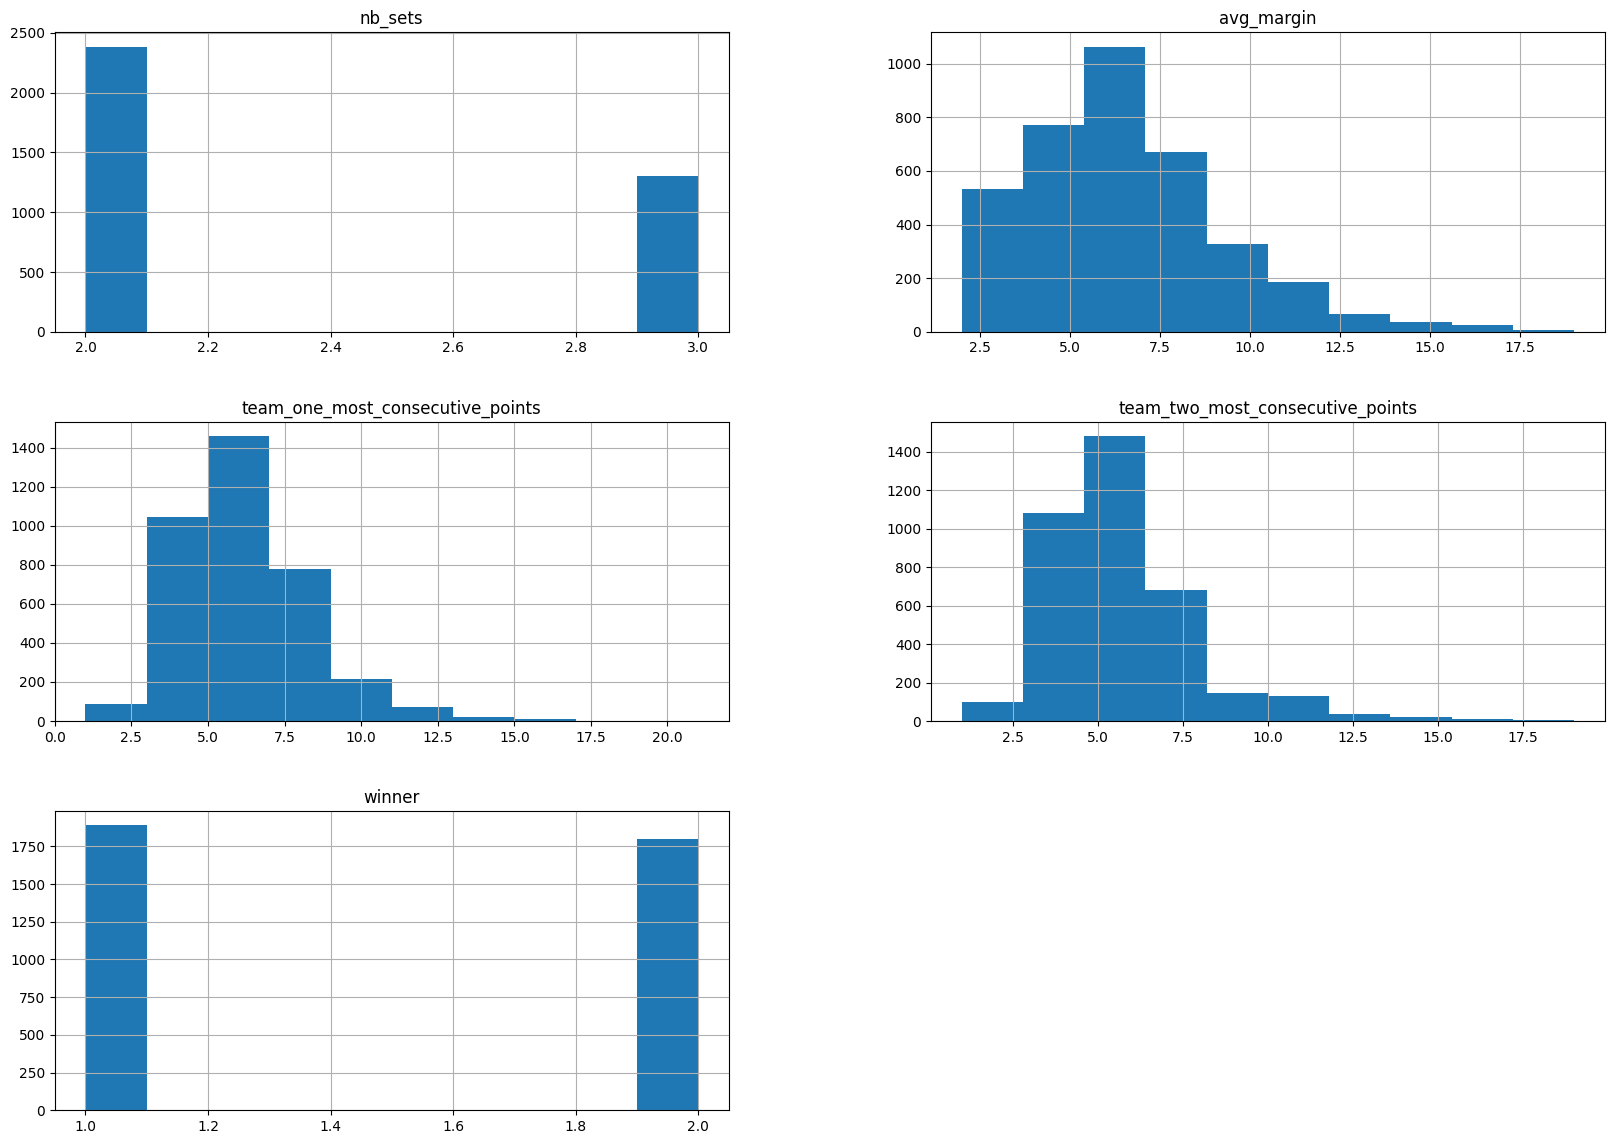

In [39]:
df.hist(figsize = (20,14))

# A bit messy, but lets us see the distributions of the different categories

In [40]:
# Train Test Split
from sklearn.model_selection import train_test_split

X = df[features]
y = df['winner'] - 1

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 0)

In [41]:
# pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipeline = Pipeline([('preprocessor', preprocessor),
                     ('clf', LogisticRegression(random_state = 0, max_iter = 10000))])

pipeline.fit(X_train,y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['nb_sets', 'avg_margin',
                                                   'team_one_most_consecutive_points',
                                                   'team_two_most_consecutive_points']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['round', 'tournament_type',
                                                   'team_one_nationalities',
                                                   'team_two_nationalities',
                                                   'tournament_tier',
                                                   'team_one_region',
                                                   'team_two_region',
                                                   'retired'])])),
                ('clf', LogisticRegression(max_iter=10000, random_state=0))])

In [42]:
# accuracy scoring
from sklearn.metrics import accuracy_score

y_pred = pipeline.predict(X_test)

accuracy_score(y_pred,y_test)

0.8082340195016251

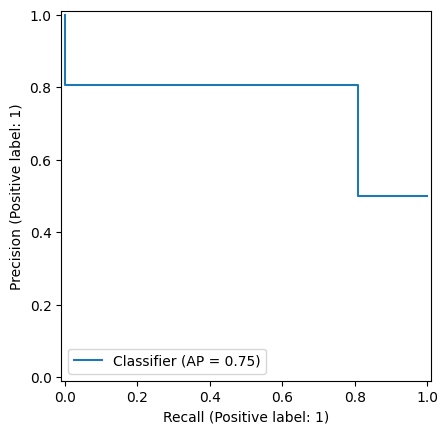

In [43]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_pred)

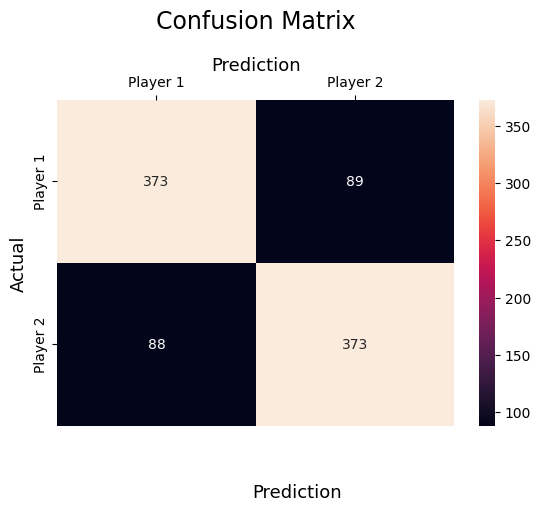

'              precision    recall  f1-score   support\n\n           0       0.81      0.81      0.81       462\n           1       0.81      0.81      0.81       461\n\n    accuracy                           0.81       923\n   macro avg       0.81      0.81      0.81       923\nweighted avg       0.81      0.81      0.81       923\n'

In [44]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm, 
            annot=True,
            fmt='g', 
            xticklabels=['Player 1','Player 2'],
            yticklabels=['Player 1','Player 2'])
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()

classification_report(y_test,y_pred)

In [45]:
feature_weights = pd.DataFrame({
    'Feature': pipeline.named_steps['preprocessor'].get_feature_names_out(),
    'Weight': pipeline.named_steps['clf'].coef_[0]
})

# the feature column had to be done this way because one_hot_encoding changes the size of the data


print(feature_weights)

                                   Feature    Weight
0                             num__nb_sets  0.013619
1                          num__avg_margin  0.052818
2    num__team_one_most_consecutive_points -1.618949
3    num__team_two_most_consecutive_points  1.565489
4                         cat__round_Final -0.420030
..                                     ...       ...
156          cat__team_two_region_americas -0.564708
157              cat__team_two_region_asia  0.775266
158            cat__team_two_region_europe -0.056614
159           cat__team_two_region_oceania -0.096377
160                     cat__retired_False -0.060187

[161 rows x 2 columns]


Since we have applied standard scaler to our data, we can use the magnitude of each weight as a rough indicator of the importance of each feature. However, there are a few caveats here. 
1. If we have two highly correlated features, it can split the weight between them. 
2. Dummy-coded variables(takes on either 1 or 0) can behave kind of weirdly
3. If logistic regression is not sufficiently predictive, then the weights don't tell us anything

In [46]:
feature_weights['Weight'] = feature_weights['Weight'].apply(np.abs)

feature_weights.sort_values(by='Weight', ascending = False).head(20)

,Feature,Weight
2,num__team_one_most_consecutive_points,1.618949
3,num__team_two_most_consecutive_points,1.565489
33,cat__team_one_nationalities_DEN,1.101371
98,cat__team_two_nationalities_DEN,1.038979
9,cat__round_Round 1,1.038000
112,cat__team_two_nationalities_ISR,0.970808
28,cat__team_one_nationalities_BUL,0.937027
104,cat__team_two_nationalities_FRA,0.875645
121,cat__team_two_nationalities_MEX,0.804536
139,cat__team_two_nationalities_SWE,0.776507


### Observations from logistic regression

After experimenting with which features to use, it turns out for the most part they return around the same mean accuracy. Furthermore, it seems that the two most important features, the ones that gives the bulk of predictive power are team_one_most_consecutive_points and team_two_most_consecutive_points.

From the logistic regression weights, we can also see that the two most important features are the most consecutive points scored. 

Now, we will check whether there exists a correlation between scoring more consecutive points and winning the set. 

In [47]:
n = data.shape[0]

def consecutive_implies_win(row):
    return (((row.team_one_most_consecutive_points >= row.team_two_most_consecutive_points) and
           row.winner == 1) or
           ((row.team_two_most_consecutive_points > row.team_one_most_consecutive_points) and 
           row.winner == 2))

data.apply(consecutive_implies_win, axis = 'columns').sum()/n

np.float64(0.7965966498271736)

A note that we should make and a point of imporvement that can be made is to clean up the interdependence of features. For instance, we have a nationality and region feature, there exists a significant correlation between these two features. Removing it could help with efficiency as well as interpretability. 

## Decision Tree Classifier
We now take advantage of the pipeline and use it to train a decision tree classifer.

In [48]:
from sklearn.tree import DecisionTreeClassifier

pipeline.set_params(clf=DecisionTreeClassifier(random_state=0))
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
accuracy_score(y_pred,y_test)

0.7573131094257854

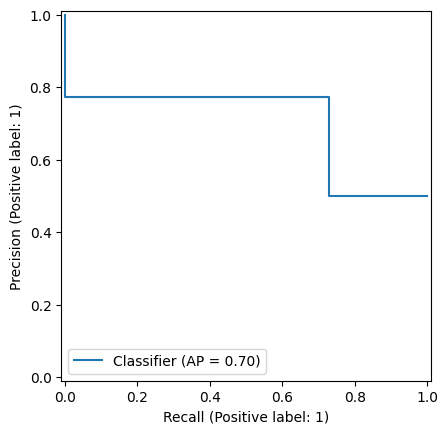

In [49]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_pred)

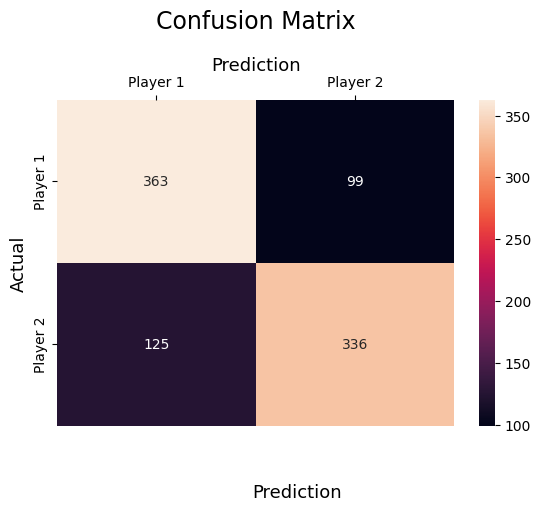

'              precision    recall  f1-score   support\n\n           0       0.74      0.79      0.76       462\n           1       0.77      0.73      0.75       461\n\n    accuracy                           0.76       923\n   macro avg       0.76      0.76      0.76       923\nweighted avg       0.76      0.76      0.76       923\n'

In [50]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm, 
            annot=True,
            fmt='g', 
            xticklabels=['Player 1','Player 2'],
            yticklabels=['Player 1','Player 2'])
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()

classification_report(y_test,y_pred)

In [65]:
from sklearn.tree import export_text, plot_tree

tree_rules = export_text(pipeline.named_steps['clf'],
            feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out(),
                        max_depth = 3)
print(tree_rules)
# This is a text based way of seeing the tree

|--- num__team_one_most_consecutive_points <= -0.55
|   |--- num__team_two_most_consecutive_points <= -0.51
|   |   |--- num__team_one_most_consecutive_points <= -1.01
|   |   |   |--- cat__team_two_nationalities_ENG <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cat__team_two_nationalities_ENG >  0.50
|   |   |   |   |--- class: 0
|   |   |--- num__team_one_most_consecutive_points >  -1.01
|   |   |   |--- num__team_two_most_consecutive_points <= -0.97
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- num__team_two_most_consecutive_points >  -0.97
|   |   |   |   |--- truncated branch of depth 17
|   |--- num__team_two_most_consecutive_points >  -0.51
|   |   |--- num__avg_margin <= -0.80
|   |   |   |--- cat__team_two_nationalities_HKG <= 0.50
|   |   |   |   |--- truncated branch of depth 18
|   |   |   |--- cat__team_two_nationalities_HKG >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- num__avg_margin >  -0.80
|   |  

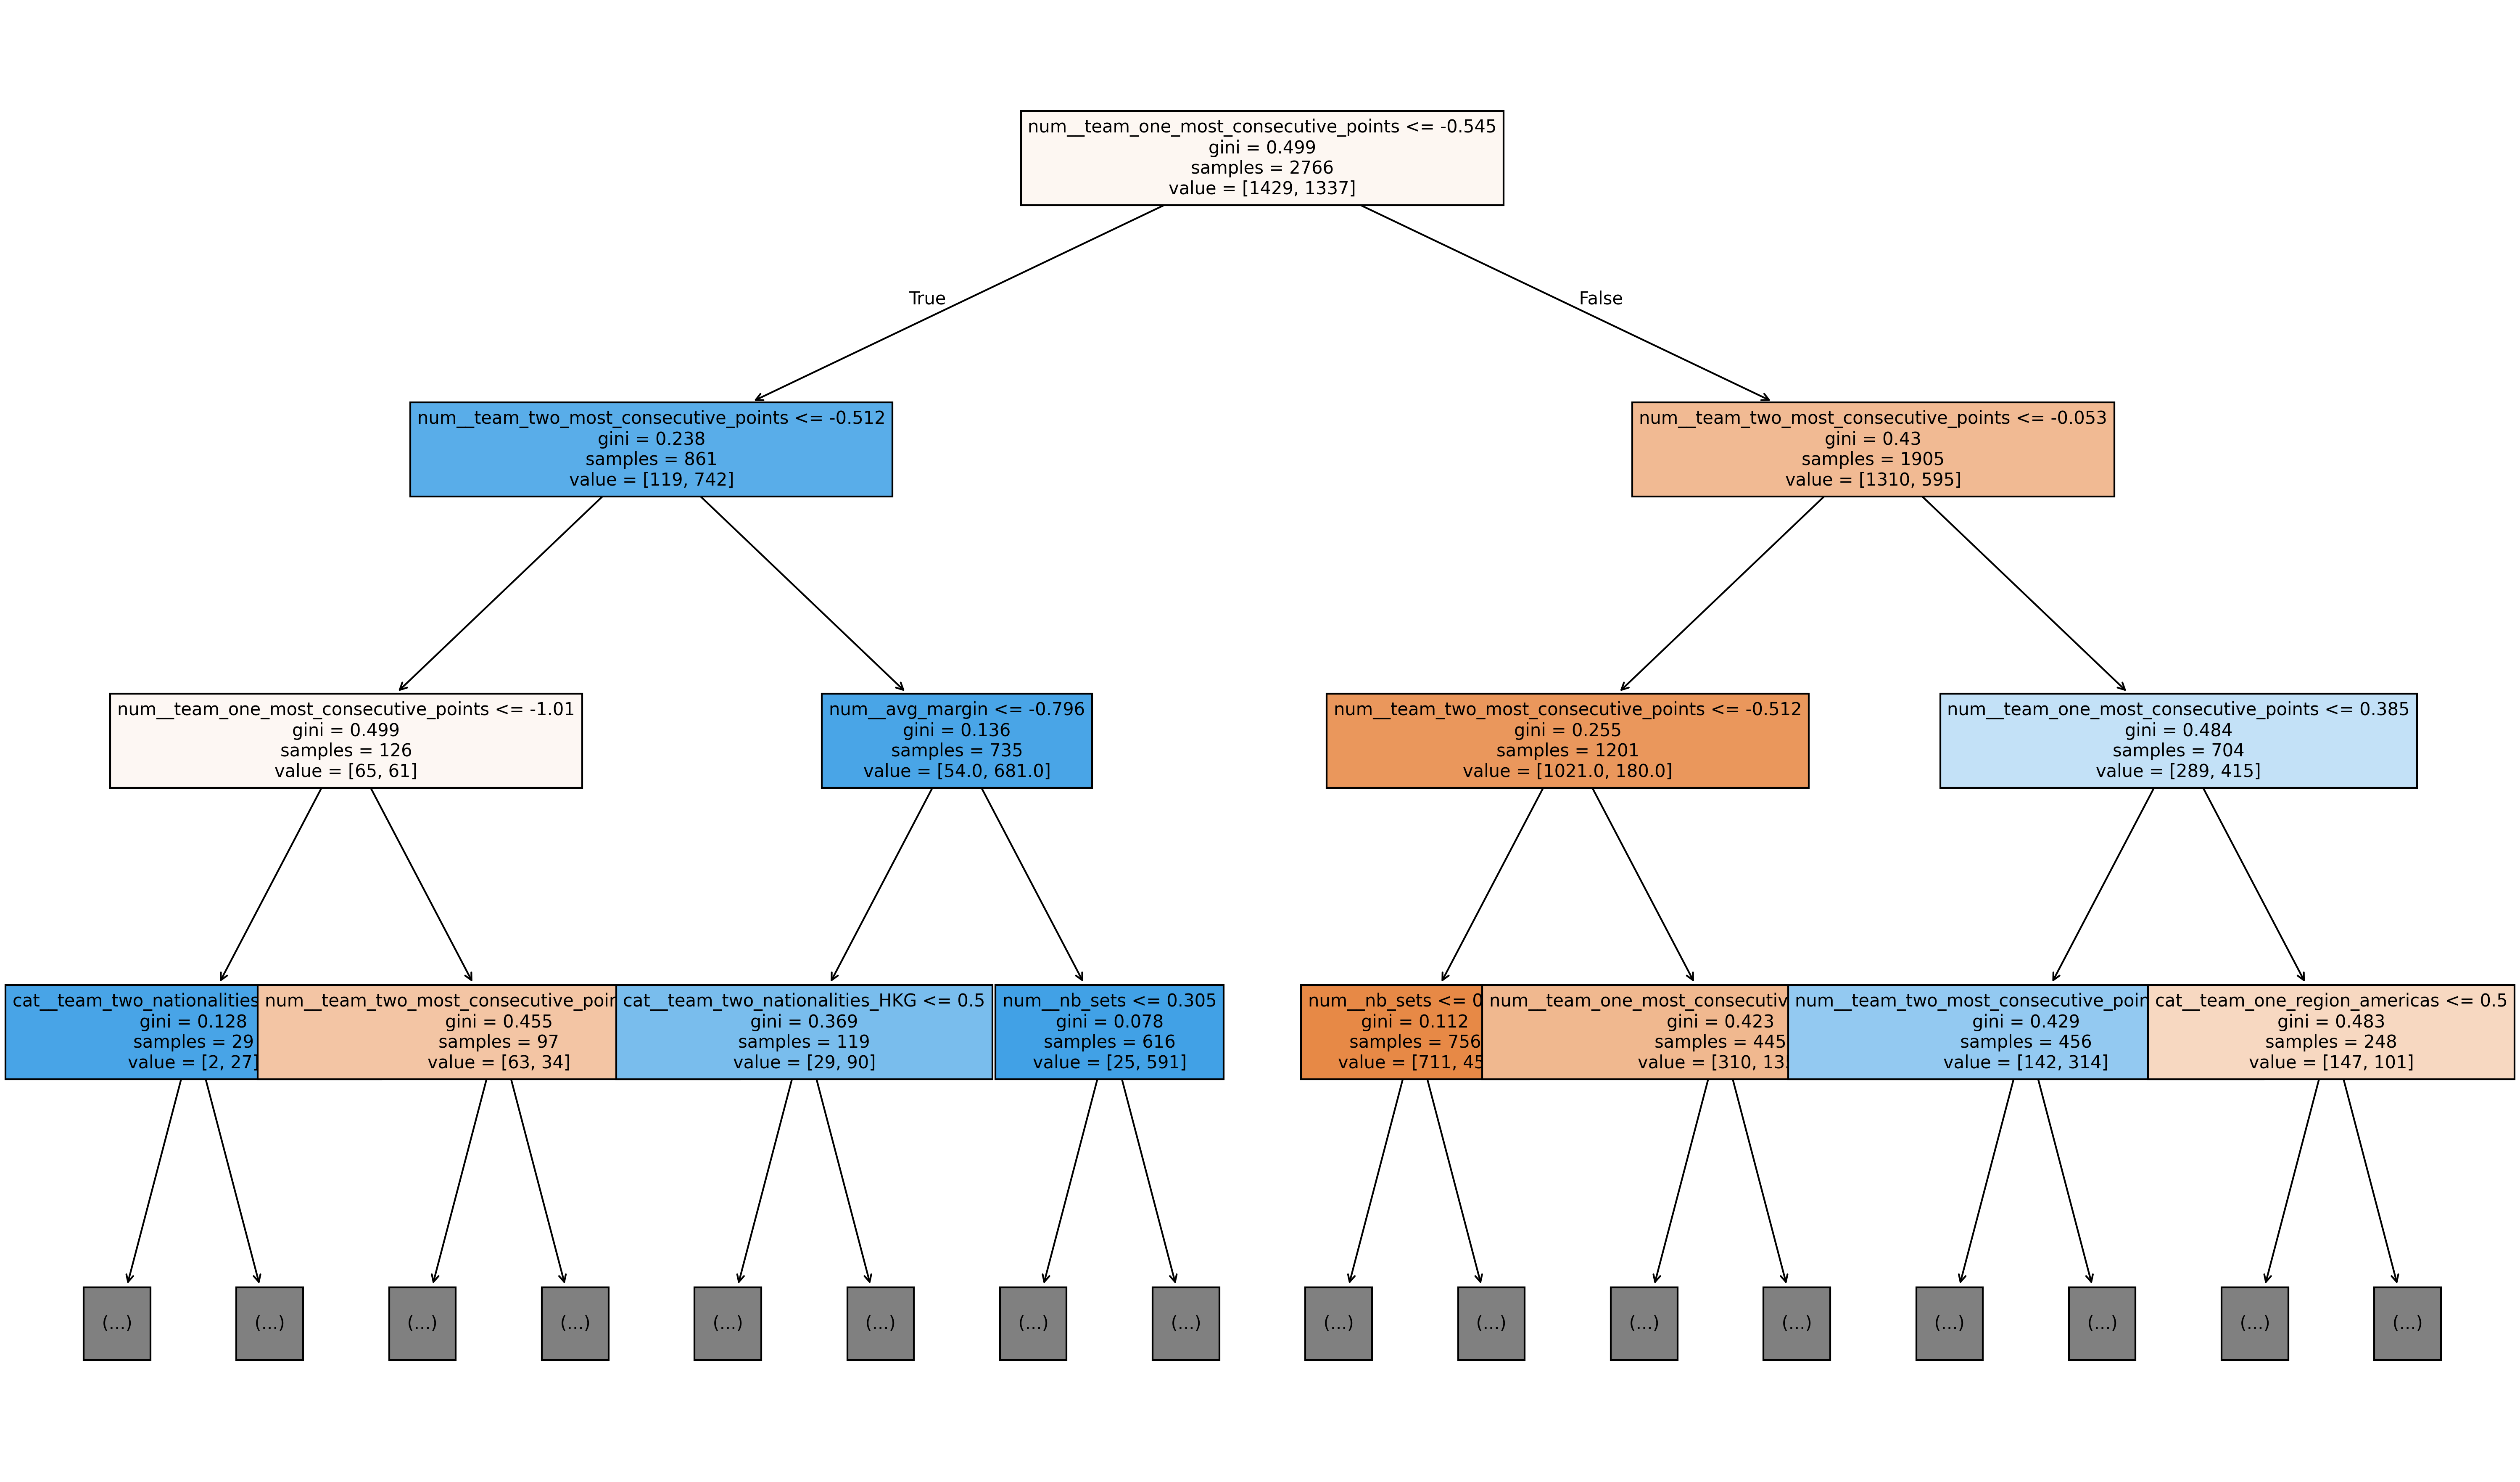

In [77]:
plt.figure(figsize = (25,15), dpi = 300)
plot_tree(pipeline.named_steps['clf'],
          feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out(),
         max_depth = 3,
         filled = True, # this tells us how skewed the remaining data is 
         fontsize = 10)
plt.show()

### Observations from Decision Tree

Recall that a decision tree is structured such that the most important splits come first. This is due to gini impurity which gives us a measure of "how good the split is" roughly speaking. We can see that the most important factor in the decision tree is the most consecutive points won. The colour of each node tells us how much that specific split will split the data in one direction over the other. In this case, not much information can be gleaned from this. 

We can also see that there are several cases in the tree where the gini impurity of the child node is much higher than that of the parent node, this also implies that the other child node has significantly lower gini impurity. This tells us that in some cases, there is a very quick way to predict the potential winner. However, we must also take into consideration that the tree may simply be too big and is try to fit a complex relationship that is purely circumstantial. Further evidence supporting this comes from the fact that a depth one tree that looks only at who has the most conseutive points has better(although not by much) accuracy. 

## Comparing The Two Models
Both models are incredibly similar in their results. They have incredibly similar metrics, whether it be accuracy, precision-recall, or even the most weighted feature. That being said, the logistic regression model does fare slightly better in nearly all metrics. However, this is likely not a very meaningful difference since the bulk of predictive power in both models seems to lie in the most consecutive points features. This should be expected, since badminton matches are inherently meant to be relatively fairly matched, and data such as nationality should not have too significant of an edge. This is a cherry-picked example, but the point is that the only real meaningful "play-based" feature is the most consecutive points feature, which is why one should expect it to contain the bulk of predictive power. 

